Default threshold (0.50) F1 : 0.8391
Optimal threshold          : 0.26
Optimal threshold F1       : 0.8830


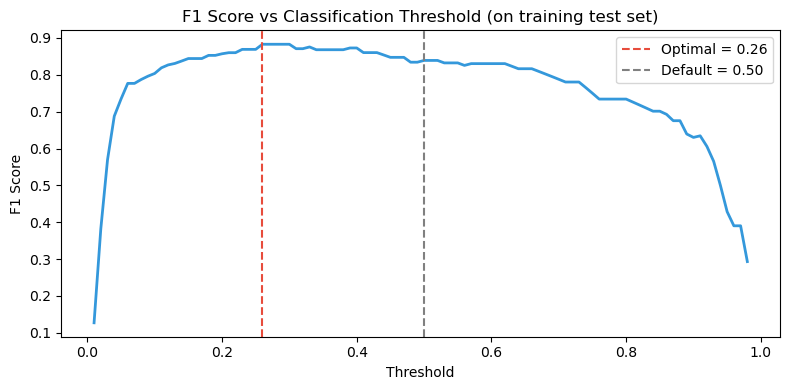


── Updated Baseline Metrics (optimal threshold) ──
  F1          : 0.8830
  AUC-ROC     : 0.9529
  Precision   : 0.9222
  Recall      : 0.8469

Optimal threshold (0.26) saved to optimal_threshold.pkl
Updated baseline_metrics.csv


In [1]:

# ─────────────────────────────────────────────
# STEP 4b: Find optimal classification threshold
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, roc_auc_score,
    precision_score, recall_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split
import joblib

# ─────────────────────────────────────────────
# 1. Load training data & model
# ─────────────────────────────────────────────
train_df = pd.read_csv("creditcard.csv")
clf      = joblib.load("baseline_model.pkl")
FEATURES = joblib.load("feature_list.pkl")

X = train_df[FEATURES]
y = train_df["Class"]

# Use the same split as Step 1 to get the held-out test set
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────
# 2. Get predicted probabilities on test set
# ─────────────────────────────────────────────
y_proba = clf.predict_proba(X_test)[:, 1]

# ─────────────────────────────────────────────
# 3. Try every threshold, find the one with best F1
# ─────────────────────────────────────────────
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"Default threshold (0.50) F1 : {f1_score(y_test, (y_proba >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold          : {best_threshold:.2f}")
print(f"Optimal threshold F1       : {best_f1:.4f}")

# ─────────────────────────────────────────────
# 4. Plot F1 vs threshold
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color="#3498db", linewidth=2)
plt.axvline(x=best_threshold, color="#e74c3c", linestyle="--",
            label=f"Optimal = {best_threshold:.2f}")
plt.axvline(x=0.50, color="grey", linestyle="--",
            label="Default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold (on training test set)")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 5. Print new baseline metrics at optimal threshold
# ─────────────────────────────────────────────
y_pred_optimal = (y_proba >= best_threshold).astype(int)

new_baseline = {
    "F1":        f1_score(y_test, y_pred_optimal),
    "AUC-ROC":   roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, y_pred_optimal, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_optimal),
}

print("\n── Updated Baseline Metrics (optimal threshold) ──")
for k, v in new_baseline.items():
    print(f"  {k:<12}: {v:.4f}")

# ─────────────────────────────────────────────
# 6. Save threshold + updated baseline
# ─────────────────────────────────────────────
joblib.dump(best_threshold, "optimal_threshold.pkl")

pd.DataFrame([new_baseline]).to_csv("baseline_metrics.csv", index=False)

print(f"\nOptimal threshold ({best_threshold:.2f}) saved to optimal_threshold.pkl")
print("Updated baseline_metrics.csv")